# 06 · Supervised Learning with scikit-learn — Part II

The heavy hitters. When a single tree or linear model isn't enough, these are what win:

- **Random forests** and **gradient boosting** — ensembles that combine many weak models.
- **Kernel SVMs** — linear models made non-linear through the "kernel trick".
- **Neural networks (MLP)** — the gateway to deep learning.
- **Predicting probabilities**, not just labels — essential for real decisions.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

d = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(d.data, d.target, test_size=0.25,
                                      random_state=42, stratify=d.target)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

## 1. Ensembles: many weak learners beat one strong one

- **Random forest**: train many trees on random subsets of data *and* features, then average.
  This averages away the overfitting a single tree suffers.
- **Gradient boosting**: build trees in sequence, each one correcting the previous errors.
  Often the top performer on tabular data.

In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xtr, ytr)
gb = GradientBoostingClassifier(random_state=0).fit(Xtr, ytr)

print(f"Random Forest    test accuracy: {rf.score(Xte, yte):.1%}")
print(f"Gradient Boosting test accuracy: {gb.score(Xte, yte):.1%}")

Random Forest    test accuracy: 95.8%
Gradient Boosting test accuracy: 95.8%


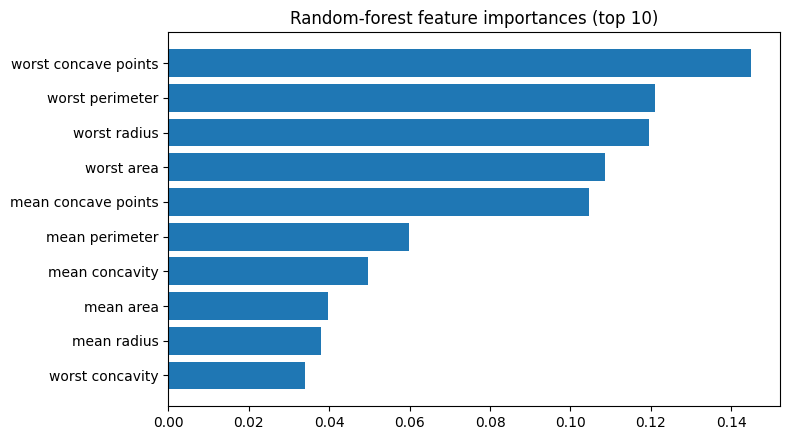

In [3]:
# Forests give stable feature importances — average over all trees
imp = rf.feature_importances_
idx = np.argsort(imp)[-10:]
plt.figure(figsize=(8, 4.5))
plt.barh(range(len(idx)), imp[idx])
plt.yticks(range(len(idx)), [d.feature_names[i] for i in idx])
plt.title("Random-forest feature importances (top 10)")
plt.tight_layout(); plt.show()

## 2. Kernel SVMs: straight lines in a curved space

A linear SVM can only draw a straight boundary. The **kernel trick** implicitly maps data
into a higher-dimensional space where a straight boundary *there* becomes a curved boundary
*here* — without ever computing that space explicitly. The `rbf` kernel is the default choice.
We visualize it on deliberately non-linear data.

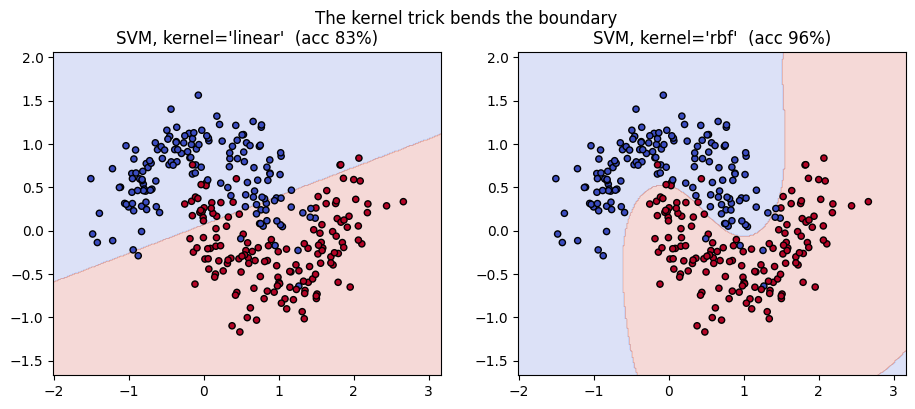

In [4]:
from sklearn.datasets import make_moons
from sklearn.svm import SVC

Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    svm = SVC(kernel=kernel, gamma="scale").fit(Xm, ym)
    xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-.5, Xm[:,0].max()+.5, 300),
                         np.linspace(Xm[:,1].min()-.5, Xm[:,1].max()+.5, 300))
    zz = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
    ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(f"SVM, kernel='{kernel}'  (acc {svm.score(Xm, ym):.0%})")
plt.suptitle("The kernel trick bends the boundary"); plt.show()

## 3. Neural networks (Multi-Layer Perceptron)

An MLP stacks layers of the linear-then-nonlinearity building block from notebook 04. With
enough hidden units it can learn very flexible boundaries. scikit-learn's `MLPClassifier` is
a fine on-ramp before you reach for PyTorch/TensorFlow. Neural nets **need scaled inputs**.

MLP test accuracy: 95.8%


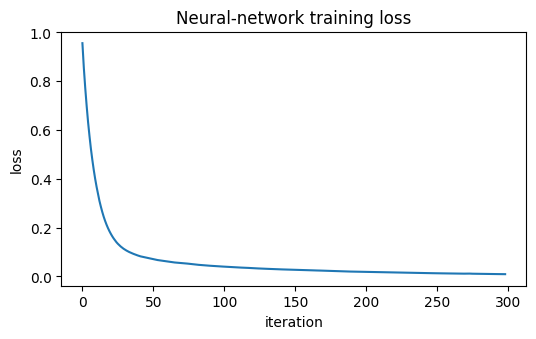

In [5]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000,
                    random_state=0).fit(Xtr_s, ytr)
print(f"MLP test accuracy: {mlp.score(Xte_s, yte):.1%}")

plt.figure(figsize=(6, 3.3))
plt.plot(mlp.loss_curve_)
plt.title("Neural-network training loss"); plt.xlabel("iteration"); plt.ylabel("loss"); plt.show()

## 4. Probabilities, not just labels

Real decisions need *confidence*: "90% likely malignant" is very different from "51% likely".
`predict_proba` returns per-class probabilities. Choosing a threshold other than 0.5 lets you
trade false positives against false negatives — the subject of notebook 09.

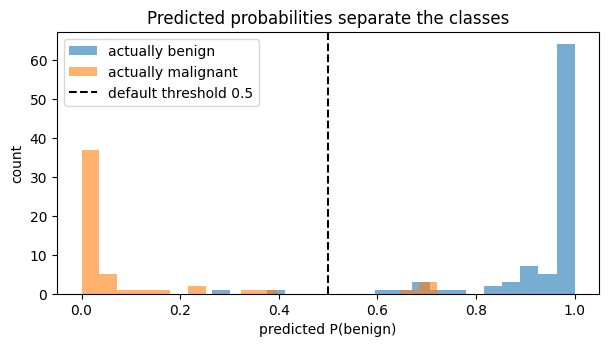

In [6]:
proba = rf.predict_proba(Xte)[:, 1]     # P(benign) for each test sample
plt.figure(figsize=(7, 3.4))
plt.hist(proba[yte == 1], bins=20, alpha=0.6, label="actually benign")
plt.hist(proba[yte == 0], bins=20, alpha=0.6, label="actually malignant")
plt.axvline(0.5, color="k", ls="--", label="default threshold 0.5")
plt.xlabel("predicted P(benign)"); plt.ylabel("count")
plt.title("Predicted probabilities separate the classes"); plt.legend(); plt.show()

## Recap

- **Random forests** average many trees; **gradient boosting** corrects errors in sequence —
  both are top tabular performers and give feature importances.
- **Kernel SVMs** draw curved boundaries via the kernel trick (`rbf`).
- **MLPs** are the neural-network on-ramp; scale inputs, watch the loss curve.
- **`predict_proba`** gives confidence; thresholds are a lever, not a fixed 0.5.

**Next:** `07 — Unsupervised Learning` — finding structure without labels.